#### **Assignment 3: Regularization and Distances**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

**Methodology**

**Part 1: Clustering**

**Dataset**
- The Human Activity Recognition dataset, with 561 engineered features
- Chosen because
    1) the number of features allows a implementation of regularization
    2) many features represent different transformations of the same underlying signals, leading to strong redundancy and correlation

**Regularization methods**
- Ridge: retains all features while shrinking their coeeficients, leading to more stable models
- Lasso: reduces number of active features, effective feature selection
- ElasticNet: compromise, preserves groups of features while still reducing sparsity 

**Part 2: Distances and Clustering**

**Task Framing**
- Unsupervised clustering on DNA-like sequences with unknown labels
- Goal: discover hidden biological structure across potentially multiple organisms

**Sequence Representation**
- k-mer frequencies (k=3): 64-dimensional compositional vector per sequence
- Normalised Hamming distance: position-aware pairwise dissimilarity, non-Euclidean, bounded [0,1]

**Clustering**
- Hierarchical clustering (average linkage) on both distance matrices
- HDBSCAN on Hamming matrix, density-based with no assumed cluster count
- Multiple methods used to cross-validate discovered structure

**Validation & Interpretation**
- Silhouette, Davies-Bouldin, and Calinski-Harabasz scores across all clusterings
- Per-cluster GC content, nucleotide frequencies, and medoid sequences for biological interpretation

#### **1. Regularization Study**

**Importing necessary libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

**Loading the dataset**

In [2]:
# Load HAR dataset
har = fetch_openml(name="HAR", version=1, as_frame=True)

df = har.frame

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print(X.shape)  
print(y.value_counts())

(10299, 561)
Class
6    1944
5    1906
4    1777
1    1722
2    1544
3    1406
Name: count, dtype: int64


**EDA**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, V1 to V561
dtypes: float64(561)
memory usage: 44.1 MB
None
      count      mean       std  min       25%       50%       75%  max
V1  10299.0  0.274347  0.067628 -1.0  0.262624  0.277174  0.288354  1.0
V2  10299.0 -0.017743  0.037128 -1.0 -0.024903 -0.017162 -0.010625  1.0
V3  10299.0 -0.108925  0.053033 -1.0 -0.121019 -0.108596 -0.097589  1.0
V4  10299.0 -0.607784  0.438694 -1.0 -0.992360 -0.943030 -0.250293  1.0
V5  10299.0 -0.510191  0.500240 -1.0 -0.976990 -0.835032 -0.057336  1.0
0


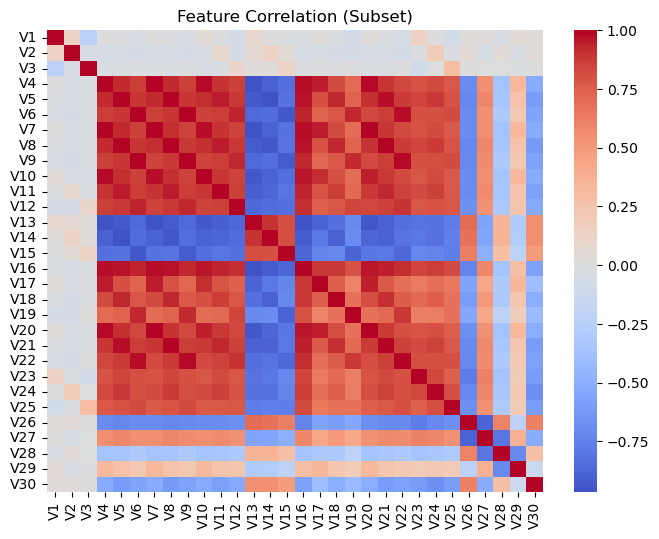

In [3]:
# Basic info
print(X.info())
print(X.describe().T.head())

# Check missing values
print(X.isnull().sum().sum())

# Correlation (subset to avoid huge plot)

subset = X.iloc[:, :30]  # first 30 features
plt.figure(figsize=(8, 6))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation (Subset)")
plt.show()

**Pre-processing**

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling with StandardScaler (mean=0, std=1) 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Define Models** 

In [5]:
# Ridge
def do_ridge(lambdaaa):
    ridge = Ridge(alpha=lambdaaa, max_iter=5000)
    
    ridge.fit(X_train, y_train)
    
    ridge_train_score = ridge.score(X_train, y_train)
    ridge_test_score = ridge.score(X_test, y_test)
    ridge_num_features = np.sum(ridge.coef_ != 0)
    ridge_coef = ridge.coef_
    
    return [round(lambdaaa, 4), round(ridge_train_score, 4), 
            round(ridge_test_score, 4), ridge_num_features], list(ridge_coef)

# LASSO
def do_lasso(lambdaaa):
    lasso = Lasso(alpha=lambdaaa, max_iter=5000)
    lasso.fit(X_train, y_train)
    
    lasso_train_score = lasso.score(X_train, y_train)
    lasso_test_score = lasso.score(X_test, y_test)
    lasso_num_features = np.sum(lasso.coef_ != 0)
    lasso_coef = lasso.coef_
    
    return [round(lambdaaa, 4), round(lasso_train_score, 4), 
            round(lasso_test_score, 4), lasso_num_features], list(lasso_coef)

# Elastic Net
def do_elastic(lambdaaa):
    elast = ElasticNet(alpha=lambdaaa, l1_ratio=0.5, max_iter=5000)
    elast.fit(X_train, y_train)
    
    elast_train_score = elast.score(X_train, y_train)
    elast_test_score = elast.score(X_test, y_test)
    elast_num_features = np.sum(elast.coef_ != 0)
    elast_coef = elast.coef_
    
    return [round(lambdaaa, 4), round(elast_train_score, 4), 
            round(elast_test_score, 4), elast_num_features], list(elast_coef)

**Ridge (L2)** 

In [6]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_ridge(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

ridge_results = pd.concat([temp_1, temp_2], axis=1)
ridge_results.head()

,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9738,0.9712,561,-0.280656,0.315687,0.059701,1.439544,1.040430,3.435252,...,0.168923,-0.149007,0.080032,-0.010337,-0.016636,0.043395,0.012038,-2.058566,-1.472830,-1.330236
1,0.0346,0.9735,0.9711,561,-0.271168,0.327253,0.044531,0.836700,-0.115349,0.895241,...,0.168138,-0.182648,0.114514,-0.012088,-0.012955,0.042302,0.011134,-1.954734,-1.357441,-1.308644
2,0.0691,0.9734,0.9710,561,-0.269422,0.330770,0.036116,0.569230,-0.428844,0.415350,...,0.161054,-0.189526,0.123029,-0.011458,-0.011927,0.041825,0.011267,-1.884915,-1.302546,-1.277685
3,0.1035,0.9733,0.9709,561,-0.267048,0.333203,0.031195,0.457276,-0.558078,0.209966,...,0.153861,-0.192745,0.127828,-0.010558,-0.011312,0.041488,0.011414,-1.823655,-1.255879,-1.249447
4,0.1380,0.9732,0.9709,561,-0.264019,0.334541,0.027841,0.395876,-0.624891,0.095805,...,0.147177,-0.194478,0.131012,-0.009605,-0.010887,0.041228,0.011544,-1.768313,-1.214204,-1.223214


**Lasso (L1)**

In [7]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_lasso(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

lasso_results = pd.concat([temp_1, temp_2], axis=1)
lasso_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.259e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9710,0.9691,337,-0.025061,0.119503,0.0,0.0,-2.477395,-0.238205,...,0.046205,-0.165284,0.129394,0.01492,-0.009352,0.040456,0.013995,-1.087261,-0.581612,-0.789304
1,0.0346,0.8723,0.8749,14,-0.000000,0.000000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
2,0.0691,0.8347,0.8371,4,-0.000000,0.000000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
3,0.1035,0.8252,0.8270,3,-0.000000,0.000000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
4,0.1380,0.8146,0.8158,3,0.000000,0.000000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000


**Elastic Net**

In [8]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_elastic(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

elastic_results = pd.concat([temp_1, temp_2], axis=1)
elastic_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.337e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9716,0.9694,411,-0.109102,0.20185,0.0,-0.0,-1.612763,-0.618667,...,0.077151,-0.183507,0.141379,0.006739,-0.007246,0.039777,0.013024,-1.129592,-0.691005,-0.846158
1,0.0346,0.9086,0.9098,51,0.000000,0.00000,0.0,0.0,-0.013507,-0.000000,...,-0.058270,0.000000,-0.000000,0.000000,0.000000,0.003385,0.000000,0.000000,0.000000,0.000000
2,0.0691,0.8587,0.8612,24,-0.000000,0.00000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
3,0.1035,0.8313,0.8339,14,-0.000000,0.00000,0.0,0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
4,0.1380,0.8235,0.8258,13,-0.000000,0.00000,0.0,-0.0,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000


**Cross validation**

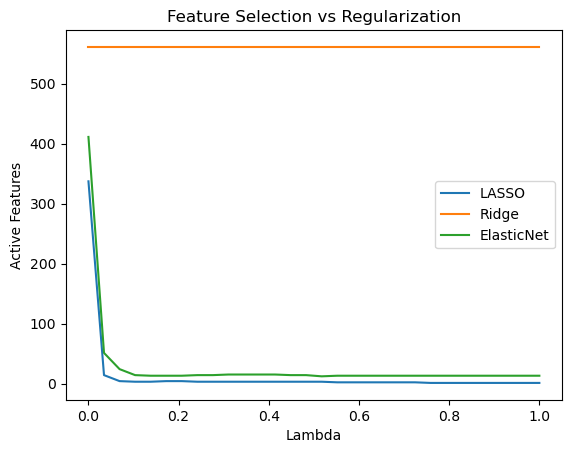

In [9]:
# number of features
plt.plot(lasso_results["Lambda"], lasso_results["Number of features"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Number of features"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Number of features"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Active Features")
plt.title("Feature Selection vs Regularization")
plt.legend()
plt.show()


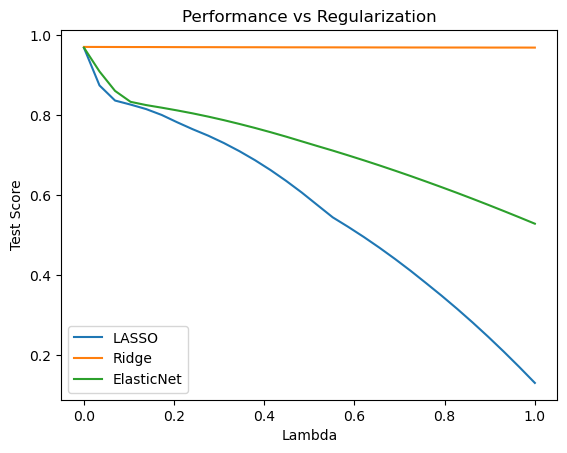

In [10]:
# train and test score
plt.plot(lasso_results["Lambda"], lasso_results["Test Score"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Test Score"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Test Score"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Test Score")
plt.title("Performance vs Regularization")
plt.legend()
plt.show()

**Conclusion**

**Features selection behavior**
- **Lasso**: sharp drop in active features even for small lambda -> aggressive feature selection
- **Ridge**: number of features stays constant (~561)
- **ElasticNet**: reduces features slightly more gradually than Lasso, stabilizes around 10-20 features -> keeps groups of correlated features

**Performance vs Regularization**
- **Lasso**: performance drops sharply as λ increases -> too aggresive, removes useful features
- **Ridge**: performance stays almost constant (~0.97) -> stable, handles correlations well
- **ElasticNet**: smoother decline than Lasso -> trade-off between sparsity and performance

#### **2. Distances and Clustering in DNA-Like Sequences**

**Importing necessary libraries**

In [1]:
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
from itertools import product
from scipy.spatial.distance import hamming, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster,set_link_color_palette
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering  
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score,pairwise_distances
import hdbscan  
from statistics import mean                                     
from sklearn.manifold import MDS, TSNE
import umap
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

**Loading the dataset**

In [2]:
data=pd.read_csv("./data/highly_classified_data.csv",sep=";")
data.head()

,ID,Sequence,Unnamed: 2
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...,NaN
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN


In [3]:
print(data['Unnamed: 2'].value_counts())
# Dropping the 'Unnamed: 2' column as it contains NaN 
data = data.drop(columns=['Unnamed: 2'])
data.sample(4)

Series([], Name: count, dtype: int64)


,ID,Sequence
83,seq84,GGAGGATTGAGGTTCAGTATCACCAAGTGCCTGACCAGGTGGTTAA...
53,seq54,ATAGGAGGTTTCGCGAAGTGGGTGATAGCCGATGGTAGCCGGCCCA...
70,seq71,ATAGGAGGTTTCGCGGAGTGGGTGATATCAGATTGTAGCCGGCCCA...
45,seq46,TTGCCGGACGTTCCCAGAGCTCCGGATGTGAACTTCGTTCACTGAT...


**EDA**

In [4]:
# Checking for missing values
print("Missing values in each column:")
print(data.isnull().sum())
# Checking for duplicates
print("Number of duplicate rows:", data.duplicated().sum())
# Length of the sequences
print("Average length of the sequences:", mean(data['Sequence'].apply(len)))
# Unique characters in the sequences
unique_characters = set(''.join(data['Sequence'].tolist()))
print(f"Unique characters in the sequences: {sorted(unique_characters)}")
all_same_length = data['Sequence'].apply(len).nunique() == 1
print(f"All sequences same length: {all_same_length}")

Missing values in each column:
ID          0
Sequence    0
dtype: int64
Number of duplicate rows: 0
Average length of the sequences: 10000
Unique characters in the sequences: ['A', 'C', 'G', 'T']
All sequences same length: True


In [5]:
# Checking for malformed sequences (non-ACGT characters)
data["valid"] = data["Sequence"].apply(lambda s: set(s).issubset(set("ACGT")))
print(f"Malformed sequences: {(~data['valid']).sum()}")

Malformed sequences: 0


- No sequences are malformed as all of them contain only A, C, G, T nucleotides

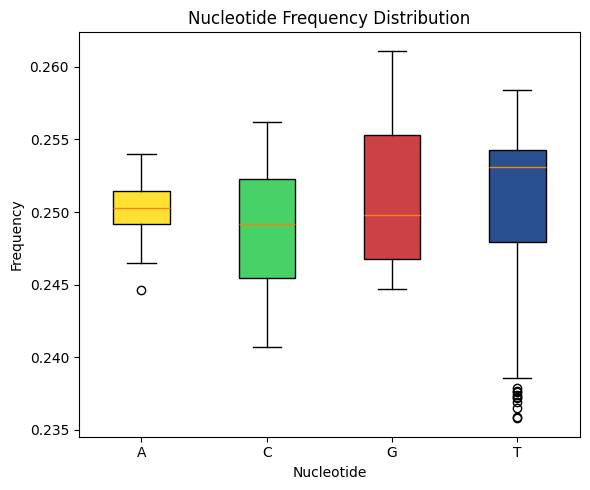

In [6]:
# Calculating frequency of each unique character in the sequences
for nuc in sorted(unique_characters):
    data[f"freq_{nuc}"] = data["Sequence"].apply(lambda s: s.count(nuc) / len(s))
fig, ax = plt.subplots(figsize=(6, 5))
freq_data = [data[f"freq_{n}"].values for n in sorted(unique_characters)]
bp = ax.boxplot(freq_data, labels=list(sorted(unique_characters)), patch_artist=True)
colors = ["#FFE134", "#47D167", "#CC4146", "#285091"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Nucleotide Frequency Distribution")
ax.set_ylabel("Frequency")
ax.set_xlabel("Nucleotide")
plt.tight_layout()
plt.show()

**Sequence representation**

In [7]:
def kmer_freq_vector(seq, k, kmer_list)-> np.ndarray:
    """
    Computing k-mer frequency vector for a sequence.
    Args:
        seq (str): Input DNA sequence.
        k (int): Length of k-mers.
        kmer_list (list): List of all possible k-mers.
    Returns:
        np.ndarray: Normalized frequency vector of k-mers.
    """
    total = len(seq) - k + 1
    counts = {km: 0 for km in kmer_list}
    for i in range(total):
        tri = seq[i:i+k]
        if tri in counts:
            counts[tri] += 1
    return np.array([counts[km] / total for km in kmer_list])
def normalized_hamming(s1, s2)-> float:
    """
    Computing normalized Hamming distance between two equal-length strings.
    Args:
        s1 (str): First string.
        s2 (str): Second string.
    Returns:
        float: Normalized Hamming distance.
    """
    assert len(s1) == len(s2), "Sequences must be equal length for Hamming."
    return sum(c1 != c2 for c1, c2 in zip(s1, s2)) / len(s1)

In [8]:
# Building the k-mer frequency matrix for k=3 (Trinucleotide frequencies)
k=3
seqs = data['Sequence'].tolist()
k_mers = [''.join(p) for p in product("ACGT", repeat=k)] #4^3=64 possible trinucleotides
kmer_matrix = np.array([kmer_freq_vector(s, k, k_mers) for s in seqs])
print(f"k-mer frequency matrix shape: {kmer_matrix.shape}")

k-mer frequency matrix shape: (100, 64)


**Distance matrix**

In [9]:
# 1. Trinucleotide frequencies (k=3) (Euclidean distance)
euclidean_matrix = pairwise_distances(kmer_matrix, metric="euclidean")
print(f"Euclidean distance matrix shape: {euclidean_matrix.shape}")
print(f"Mean pairwise Euclidean distance: {euclidean_matrix[euclidean_matrix > 0].mean():.4f}")

Euclidean distance matrix shape: (100, 100)
Mean pairwise Euclidean distance: 0.0120


In [10]:
# 2. Normalized Hamming distance matrix (Non-euclidean distance)
hamming_matrix = np.zeros((len(seqs), len(seqs)))
for i in range(len(seqs)):
    for j in range(i + 1, len(seqs)):
        d = normalized_hamming(seqs[i], seqs[j])
        hamming_matrix[i, j] = d
        hamming_matrix[j, i] = d
print(f"Hamming distance matrix shape: {hamming_matrix.shape}")
print(f"Mean pairwise distance: {hamming_matrix[hamming_matrix > 0].mean():.4f}")

Hamming distance matrix shape: (100, 100)
Mean pairwise distance: 0.5829


**Clustering**

In [11]:
# Applying hierarchical clustering (average linkage) on Euclidean distance matrix
condensed_euc = squareform(euclidean_matrix)
linkage_euc = linkage(condensed_euc, method="average")
euclidean_labels = fcluster(linkage_euc, t=3, criterion="maxclust")
data["cluster_euclidean"] = euclidean_labels
print(f"Euclidean hierarchical counts:\n{pd.Series(euclidean_labels).value_counts()}")

Euclidean hierarchical counts:
3    50
2    25
1    25
Name: count, dtype: int64


In [12]:
# Applying hierarchical clustering (average linkage) on Hamming distance matrix
condensed_ham = squareform(hamming_matrix)
linkage_ham = linkage(condensed_ham, method="average")
hamming_labels = fcluster(linkage_ham, t=3, criterion="maxclust")
data["cluster_hamming"] = hamming_labels
print(f"Hamming hierarchical counts:\n{pd.Series(hamming_labels).value_counts()}")


Hamming hierarchical counts:
1    50
2    25
3    25
Name: count, dtype: int64


In [13]:
# Applying HDBSCAN on precomputed Hamming matrix (density-based, no cluster count assumption)
clusterer = hdbscan.HDBSCAN(metric="precomputed", min_cluster_size=5, min_samples=3)
hdbscan_labels = clusterer.fit_predict(hamming_matrix)
data["cluster_hdbscan"] = hdbscan_labels
print(f"HDBSCAN counts (-1 = noise):\n{pd.Series(hdbscan_labels).value_counts()}")

HDBSCAN counts (-1 = noise):
0    25
3    25
2    25
1    25
Name: count, dtype: int64


In [14]:
# Checking label agreement between Euclidean and Hamming hierarchical clustering
agreement = np.mean(euclidean_labels == hamming_labels)
print(f"Label agreement (Euclidean vs Hamming hierarchical): {agreement:.2%}")

Label agreement (Euclidean vs Hamming hierarchical): 25.00%


**Visualisations**

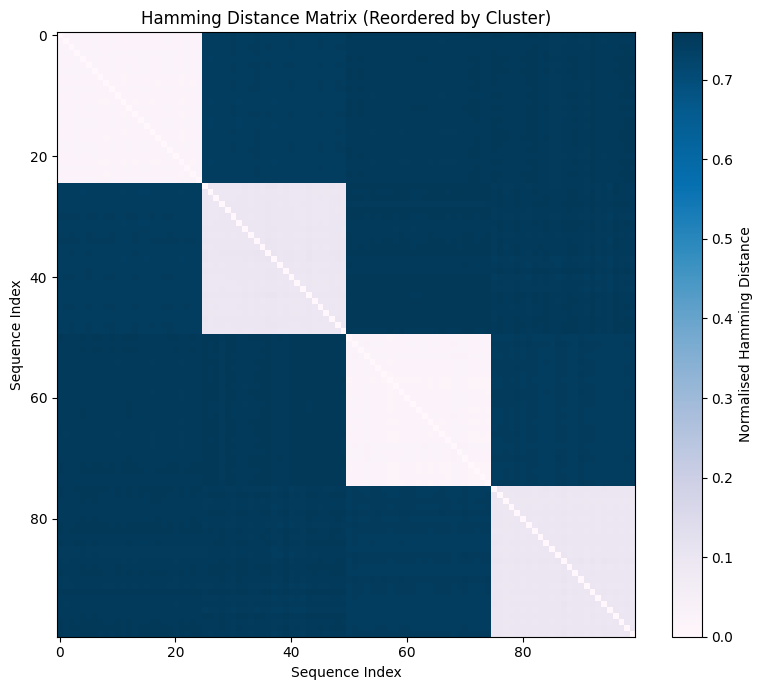

In [15]:
# Plotting Hamming distance matrix heatmap reordered by Hamming cluster labels
order = np.argsort(hamming_labels)
reordered = hamming_matrix[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(reordered, cmap="PuBu", aspect="auto")
plt.colorbar(im, ax=ax, label="Normalised Hamming Distance")
ax.set_title("Hamming Distance Matrix (Reordered by Cluster)")
ax.set_xlabel("Sequence Index")
ax.set_ylabel("Sequence Index")
plt.tight_layout()
plt.show()

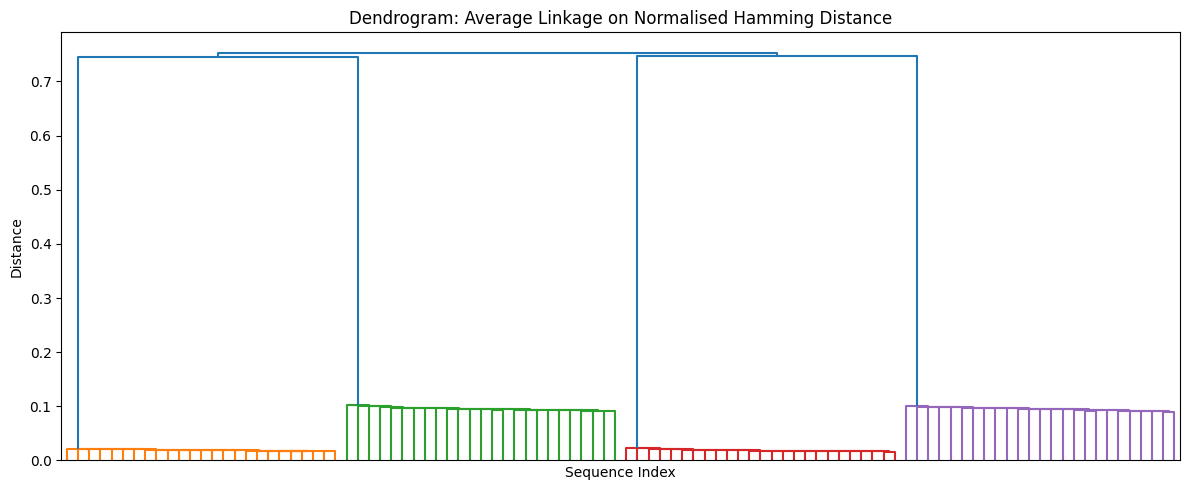

In [16]:
# Plotting dendrogram from Hamming hierarchical clustering
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_ham, ax=ax, no_labels=True, color_threshold=0.5)
ax.set_title("Dendrogram: Average Linkage on Normalised Hamming Distance")
ax.set_xlabel("Sequence Index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [17]:
# Projecting k-mer matrix to 2D using UMAP for visualisation
reducer = umap.UMAP(n_components=2, random_state=42, metric="euclidean")
embedding = reducer.fit_transform(kmer_matrix)
data["umap_x"] = embedding[:, 0]
data["umap_y"] = embedding[:, 1]

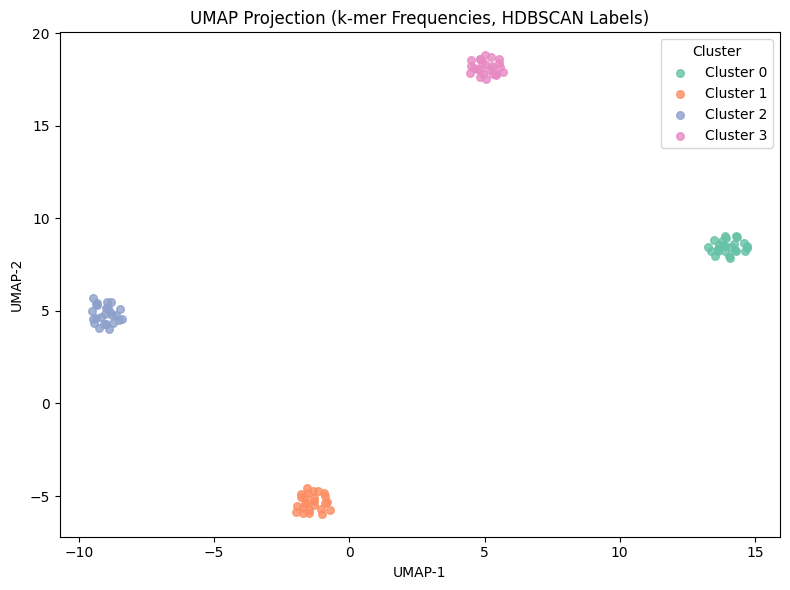

In [18]:
# Plotting UMAP projection coloured by HDBSCAN labels
palette = plt.cm.Set2.colors
unique_labels = sorted(set(hdbscan_labels))
fig, ax = plt.subplots(figsize=(8, 6))
for label in unique_labels:
    mask = hdbscan_labels == label
    color = "grey" if label == -1 else palette[label % len(palette)]
    name = "Noise" if label == -1 else f"Cluster {label}"
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=[color], label=name, s=30, alpha=0.8)
ax.set_title("UMAP Projection (k-mer Frequencies, HDBSCAN Labels)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

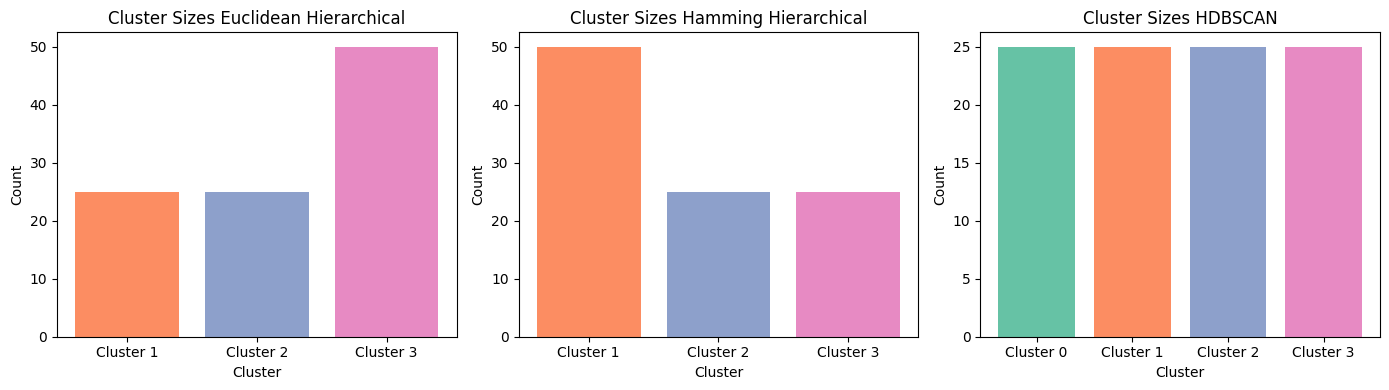

In [19]:
# Plotting cluster size distribution for all three clustering methods
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, labels, title in zip(
    axes,
    [euclidean_labels, hamming_labels, hdbscan_labels],
    ["Euclidean Hierarchical", "Hamming Hierarchical", "HDBSCAN"]
):
    counts = pd.Series(labels).value_counts().sort_index()
    labels_str = ["Noise" if l == -1 else f"Cluster {l}" for l in counts.index]
    bar_colors = ["grey" if l == -1 else palette[l % len(palette)] for l in counts.index]
    ax.bar(labels_str, counts.values, color=bar_colors)
    ax.set_title(f"Cluster Sizes {title}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Cluster validation**

In [20]:
# Computing silhouette scores on Hamming precomputed matrix
mask_valid = hdbscan_labels != -1
sil_hdbscan = silhouette_score(hamming_matrix[np.ix_(mask_valid, mask_valid)],hdbscan_labels[mask_valid],metric="precomputed")
sil_hamming = silhouette_score(hamming_matrix, hamming_labels, metric="precomputed")
sil_euclidean = silhouette_score(hamming_matrix, euclidean_labels, metric="precomputed")
print(f"Silhouette HDBSCAN (Hamming):{sil_hdbscan:.4f}")
print(f"Silhouette Hamming Hierarchical:{sil_hamming:.4f}")
print(f"Silhouette Euclidean Hierarchical:{sil_euclidean:.4f}")

Silhouette HDBSCAN (Hamming):0.9219
Silhouette Hamming Hierarchical:0.6891
Silhouette Euclidean Hierarchical:0.6719


In [21]:
# Computing Davies-Bouldin and Calinski-Harabasz on k-mer Euclidean space
db_ham = davies_bouldin_score(kmer_matrix, hamming_labels)
db_euc = davies_bouldin_score(kmer_matrix, euclidean_labels)
ch_ham = calinski_harabasz_score(kmer_matrix, hamming_labels)
ch_euc = calinski_harabasz_score(kmer_matrix, euclidean_labels)
print(f"Davies-Bouldin  (lower = better) Hamming:   {db_ham:.4f}")
print(f"Davies-Bouldin  (lower = better)  Euclidean: {db_euc:.4f}")
print(f"Calinski-Harabasz (higher = better) Hamming:   {ch_ham:.4f}")
print(f"Calinski-Harabasz (higher = better) Euclidean: {ch_euc:.4f}")


Davies-Bouldin  (lower = better) Hamming:   1.1925
Davies-Bouldin  (lower = better)  Euclidean: 1.0004
Calinski-Harabasz (higher = better) Hamming:   40.6284
Calinski-Harabasz (higher = better) Euclidean: 63.9777


**Within cluster sequence analysis**

In [22]:
# Computing mean nucleotide frequencies per HDBSCAN cluster
data["cluster"] = hdbscan_labels
nuc_cols = [f"freq_{n}" for n in sorted(unique_characters)]
cluster_nuc_stats = data.groupby("cluster")[nuc_cols].mean().round(4)
print("Mean nucleotide frequencies per cluster:")
cluster_nuc_stats

Mean nucleotide frequencies per cluster:


,freq_A,freq_C,freq_G,freq_T
cluster,,,,
0,0.2503,0.2519,0.2457,0.2521
1,0.2509,0.2535,0.2569,0.2386
2,0.2482,0.2431,0.2539,0.2547
3,0.2516,0.2463,0.2479,0.2541


In [23]:
# Computing GC content per cluster
data["gc_content"] = data["Sequence"].apply(
    lambda s: (s.count("G") + s.count("C")) / len(s))
gc_per_cluster = data.groupby("cluster")["gc_content"].agg(["mean", "std"]).round(4)
print("GC content per cluster:")
gc_per_cluster

GC content per cluster:


,mean,std
cluster,,
0,0.4976,0.0008
1,0.5105,0.0020
2,0.4971,0.0017
3,0.4943,0.0008


In [24]:
# Identifying medoid (most central sequence) per cluster using Hamming matrix
print("Medoids per cluster:")
for label in sorted(set(hdbscan_labels)):
    if label == -1:
        continue
    indices = np.where(hdbscan_labels == label)[0]
    sub_matrix = hamming_matrix[np.ix_(indices, indices)]
    medoid_local = np.argmin(sub_matrix.sum(axis=1))
    medoid_global = indices[medoid_local]
    print(f"Cluster {label}: index {medoid_global} | {seqs[medoid_global][:50]}...")

Medoids per cluster:
Cluster 0: index 21 | CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAATAGG...
Cluster 1: index 91 | GGAGGCTTGAGGTTCAGTATCCCCCAGTGCATGACCGGGTGGTTAATGTC...
Cluster 2: index 50 | AAAGGAGGTTTCGCGAAGTGGGTGATAGCAGATGGTAGCCGGCCCATCGG...
Cluster 3: index 25 | TTGCCGGACGTTCCCAGACCTCCGAATGTGAACTTCGTTCACTTCTGAAT...


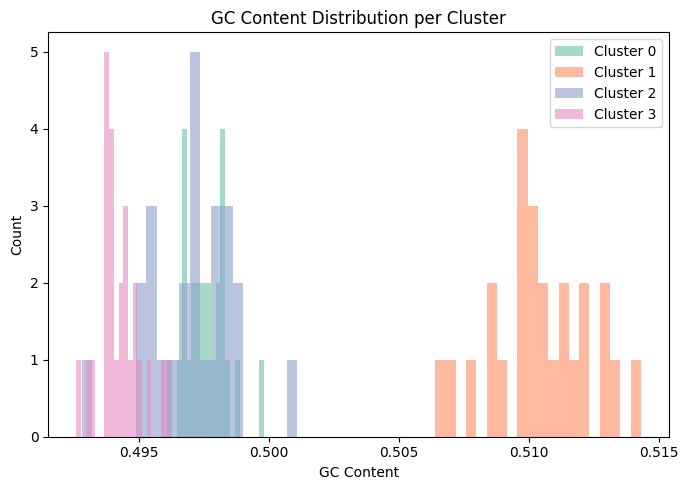

In [25]:
# Plotting GC content distribution per cluster
fig, ax = plt.subplots(figsize=(7, 5))
for label in sorted(set(hdbscan_labels)):
    subset = data[data["cluster"] == label]["gc_content"]
    color = "grey" if label == -1 else palette[label % len(palette)]
    name = "Noise" if label == -1 else f"Cluster {label}"
    ax.hist(subset, bins=20, alpha=0.6, color=color, label=name)
ax.set_title("GC Content Distribution per Cluster")
ax.set_xlabel("GC Content")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

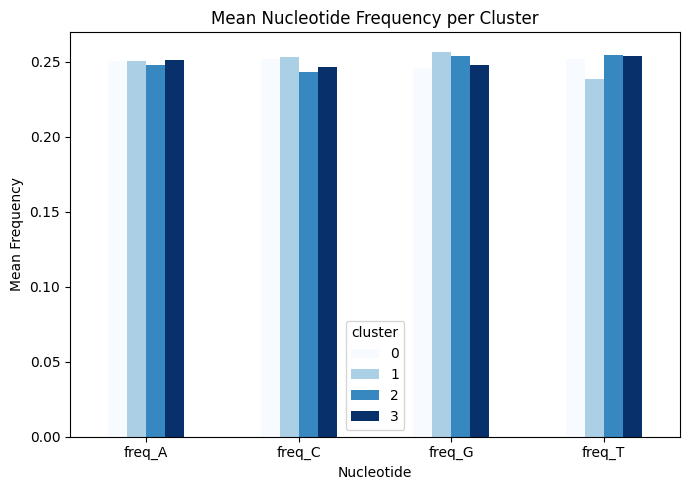

In [26]:
# Plotting mean nucleotide frequencies per cluster as grouped bar chart
cluster_nuc_stats.T.plot(kind="bar", figsize=(7, 5), colormap="Blues")
plt.title("Mean Nucleotide Frequency per Cluster")
plt.xlabel("Nucleotide")
plt.ylabel("Mean Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Metrics Conclusion**

**Conclusion**

**Take-away**

**1. Regularization**

- 
- 



**2. Distances**

- 
- 